# LSTM Demand Forecasting — Notes & Process Flow

## Project Overview

This notebook develops a Long Short-Term Memory (LSTM) neural network for time-series demand forecasting.

The objective is to use historical demand patterns and engineered time-series features to predict future demand.

The model uses a **30-day look-back window** to learn temporal patterns from the historical data.

---

## Forecasting Approach

The project follows a deep-learning-based time-series forecasting workflow.

### Key Components

- Time-series data preparation
- Date conversion and chronological sorting
- Feature preparation
- Chronological train/test split
- Feature scaling
- Time-window sequence generation
- LSTM neural network
- Model training
- Early stopping
- Forecast generation
- Model evaluation

---

## LSTM Model Architecture

The LSTM model uses:

```text
Input Sequence
      ↓
30 Time Steps
      ↓
LSTM Layer
64 Units
      ↓
Dense Layer
1 Unit
      ↓
Demand Forecast

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## LSTM Process Flow

```text
Business Problem
       ↓
Load Demand Data
       ↓
Date Conversion & Sorting
       ↓
Feature Preparation
       ↓
Chronological Train/Test Split
       ↓
Feature Scaling
       ↓
30-Day Look-Back Sequence Creation
       ↓
LSTM Model Construction
       ↓
Model Training
       ↓
Early Stopping
       ↓
Generate Predictions
       ↓
Forecast Evaluation
       ↓
Actual vs Predicted Analysis
       ↓
Business Interpretation

In [2]:
df=pd.read_csv(r"C:\Users\tg_mu\Data Science\GitHub\Time Series Forecasting\train.csv")
df.head()

,date,store,item,sales
0,2013-01-01,1,1,13
1,2013-01-02,1,1,11
2,2013-01-03,1,1,14
3,2013-01-04,1,1,13
4,2013-01-05,1,1,10


In [3]:
df.shape

(913000, 4)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 913000 entries, 0 to 912999
Data columns (total 4 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   date    913000 non-null  object
 1   store   913000 non-null  int64 
 2   item    913000 non-null  int64 
 3   sales   913000 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 27.9+ MB


In [5]:
df.isnull().sum()

date     0
store    0
item     0
sales    0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df['date']=pd.to_datetime(df['date'])

In [8]:
df=df.sort_values('date').reset_index(drop=True)

In [9]:
df.describe()

,date,store,item,sales
count,913000,913000.000000,913000.000000,913000.000000
mean,2015-07-02 12:00:00.000000256,5.500000,25.500000,52.250287
min,2013-01-01 00:00:00,1.000000,1.000000,0.000000
25%,2014-04-02 00:00:00,3.000000,13.000000,30.000000
50%,2015-07-02 12:00:00,5.500000,25.500000,47.000000
75%,2016-10-01 00:00:00,8.000000,38.000000,70.000000
max,2017-12-31 00:00:00,10.000000,50.000000,231.000000
std,NaN,2.872283,14.430878,28.801144


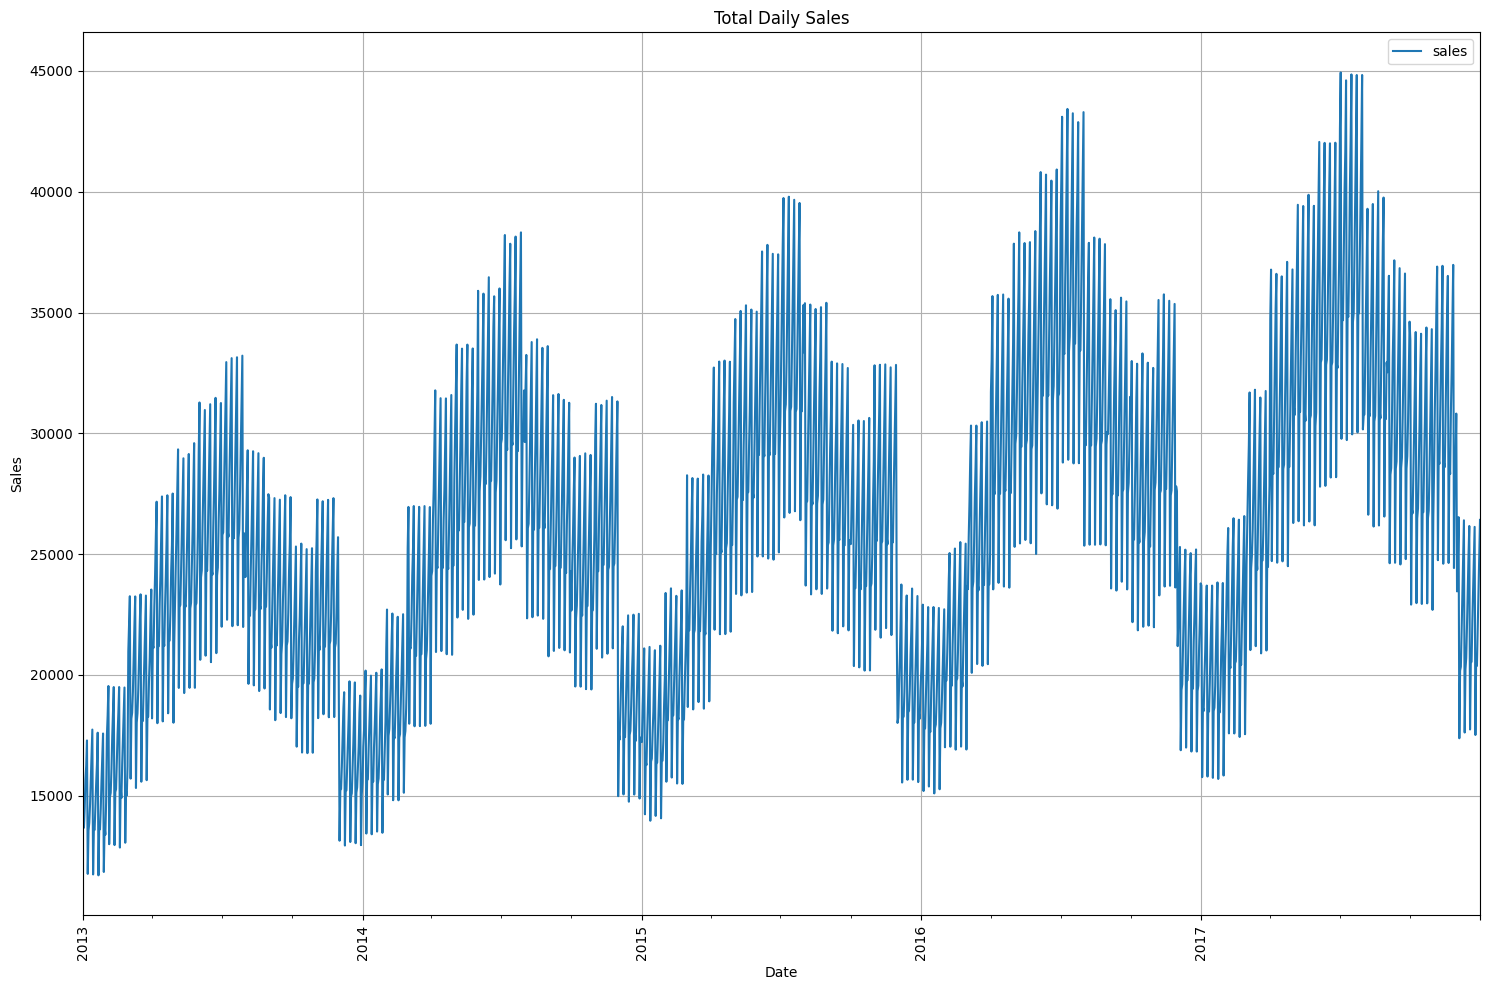

In [10]:
#Total daily sales
total_daily_sales=df.groupby('date')['sales'].sum()
total_daily_sales.plot(figsize=(15,10))
plt.title('Total Daily Sales')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.xticks(rotation=90)
plt.legend()
plt.tight_layout()
plt.grid()
plt.show()

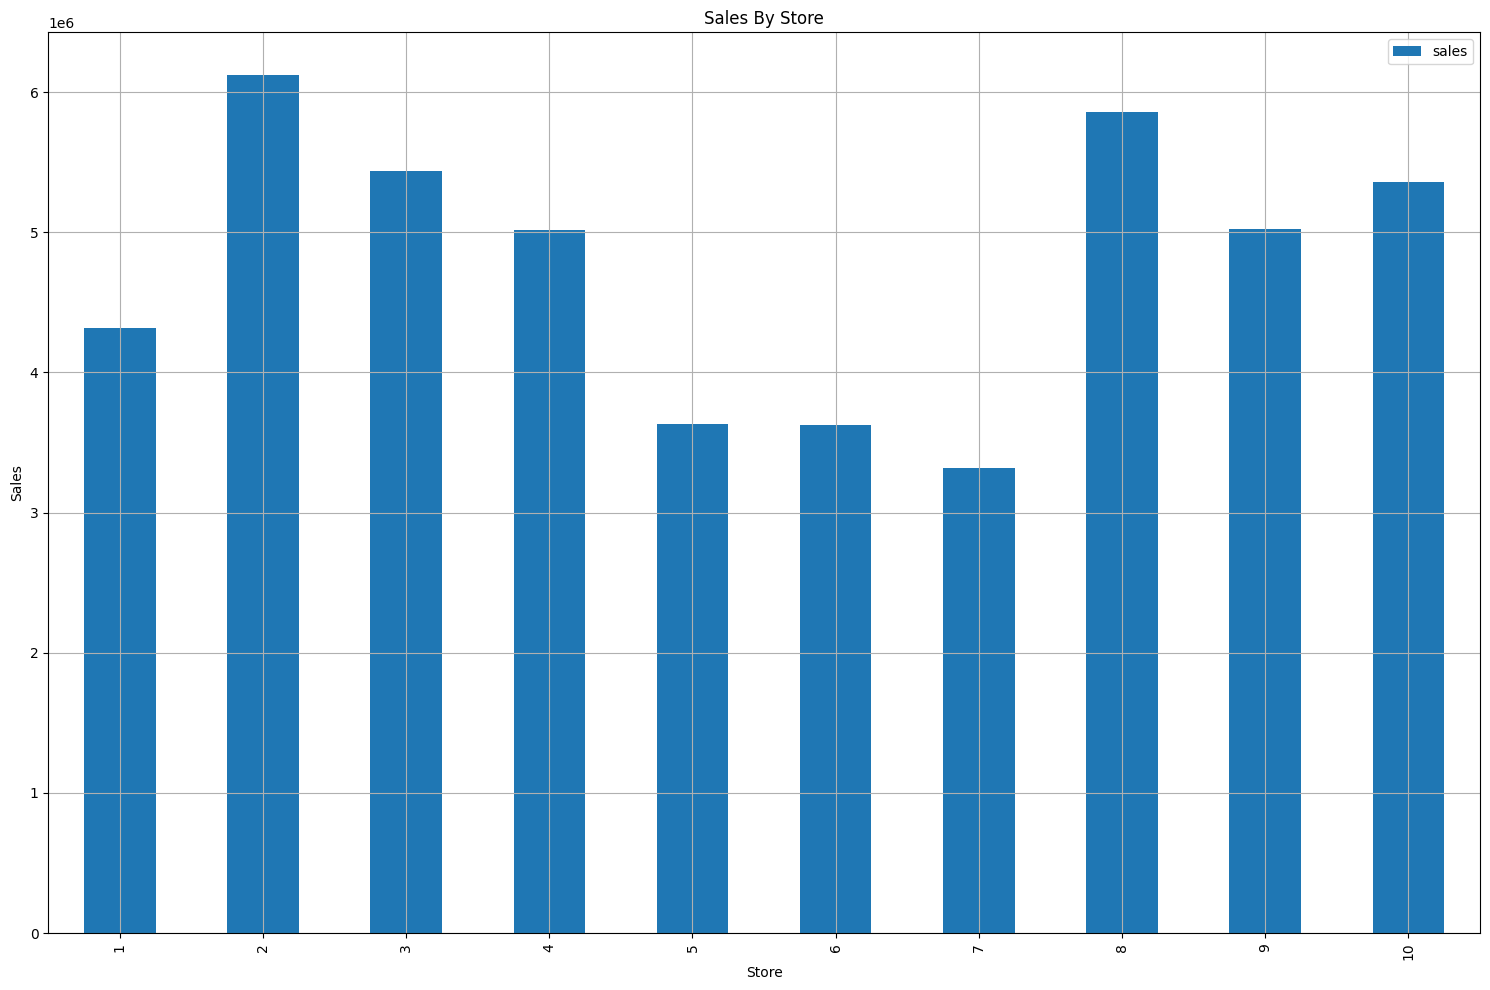

In [11]:
#Sales by store
sales_store=df.groupby('store')['sales'].sum()
sales_store.plot.bar(figsize=(15,10))
plt.title('Sales By Store')
plt.xlabel('Store')
plt.ylabel('Sales')
plt.xticks(rotation=90)
plt.legend()
plt.tight_layout()
plt.grid()
plt.show()

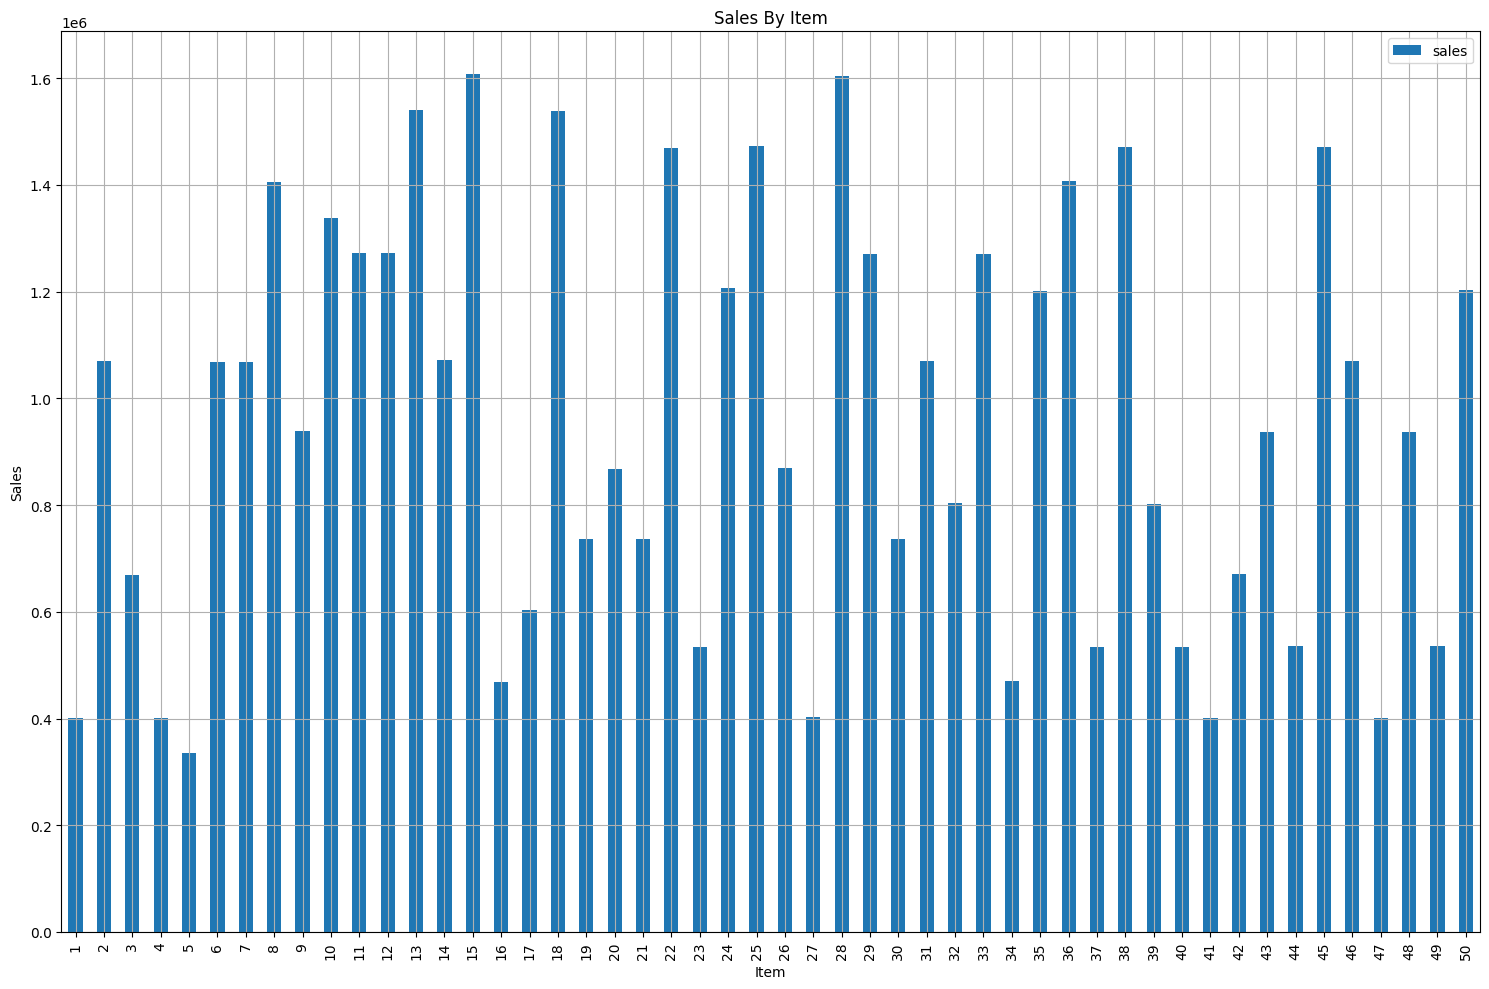

In [12]:
#Sales by item
sales_item=df.groupby('item')['sales'].sum()
sales_item.plot.bar(figsize=(15,10))
plt.title('Sales By Item')
plt.xlabel('Item')
plt.ylabel('Sales')
plt.xticks(rotation=90)
plt.legend()
plt.tight_layout()
plt.grid()
plt.show()

In [13]:
import datetime as dt

In [14]:
#Monthly,weekly,yearly trends
df['day']=df['date'].dt.day_name()
df['week']=df['date'].dt.isocalendar().week
df['month']=df['date'].dt.month
df['quarter']=df['date'].dt.quarter
df['year']=df['date'].dt.year
df['dayofweek']=df['date'].dt.day_of_week
df['is_weekend']=df['dayofweek'].isin([5,6])

In [15]:
df

,date,store,item,sales,day,week,month,quarter,year,dayofweek,is_weekend
0,2013-01-01,1,1,13,Tuesday,1,1,1,2013,1,False
1,2013-01-01,7,12,26,Tuesday,1,1,1,2013,1,False
2,2013-01-01,7,46,27,Tuesday,1,1,1,2013,1,False
3,2013-01-01,8,12,54,Tuesday,1,1,1,2013,1,False
4,2013-01-01,9,12,35,Tuesday,1,1,1,2013,1,False
...,...,...,...,...,...,...,...,...,...,...,...
912995,2017-12-31,9,34,21,Sunday,52,12,4,2017,6,True
912996,2017-12-31,10,34,32,Sunday,52,12,4,2017,6,True
912997,2017-12-31,1,35,55,Sunday,52,12,4,2017,6,True
912998,2017-12-31,8,33,100,Sunday,52,12,4,2017,6,True


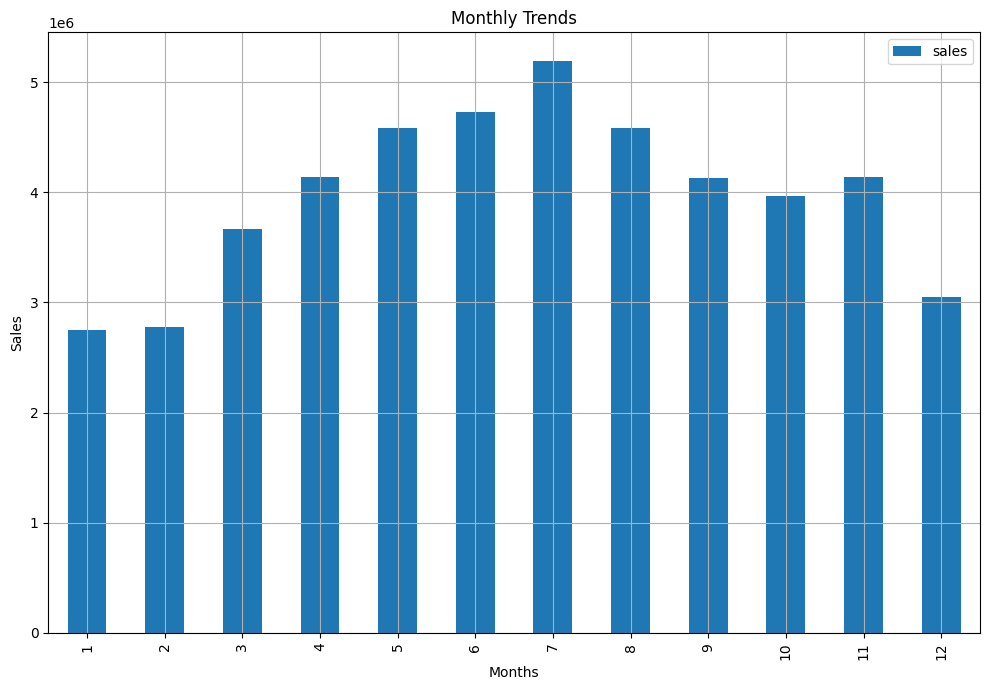

In [16]:
#monthy trends
monthly_trends=df.groupby('month')['sales'].sum()
monthly_trends.plot.bar(figsize=(10,7))
plt.title('Monthly Trends')
plt.xlabel('Months')
plt.ylabel('Sales')
plt.xticks(rotation=90)
plt.legend()
plt.tight_layout()
plt.grid()
plt.show()

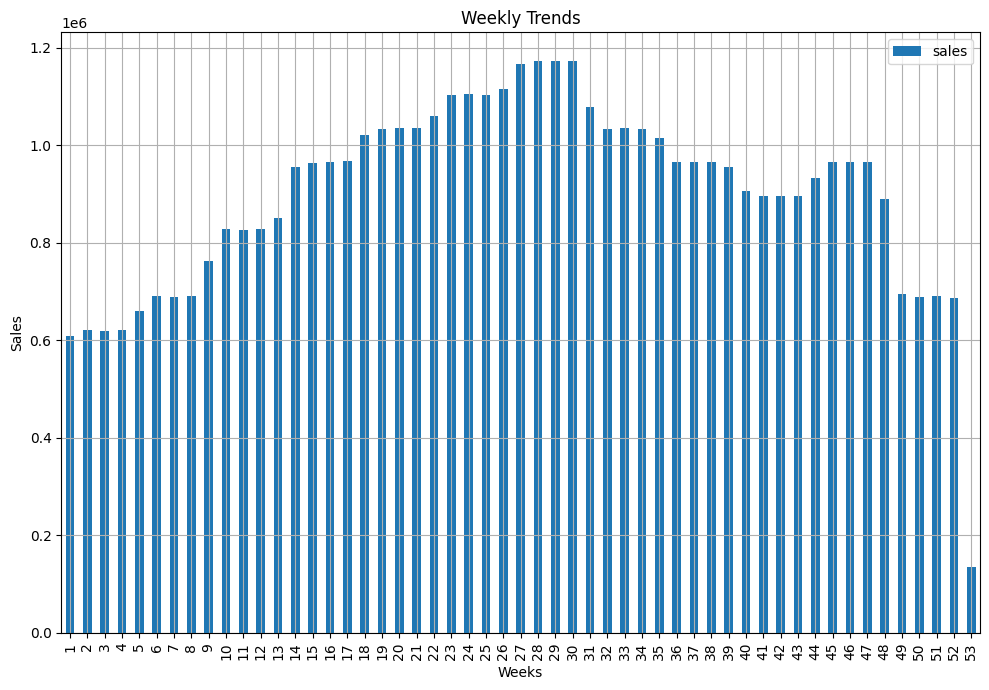

In [17]:
#weekly trends
weekly_trends=df.groupby('week')['sales'].sum()
weekly_trends.plot.bar(figsize=(10,7))
plt.title('Weekly Trends')
plt.xlabel('Weeks')
plt.ylabel('Sales')
plt.xticks(rotation=90)
plt.legend()
plt.tight_layout()
plt.grid()
plt.show()

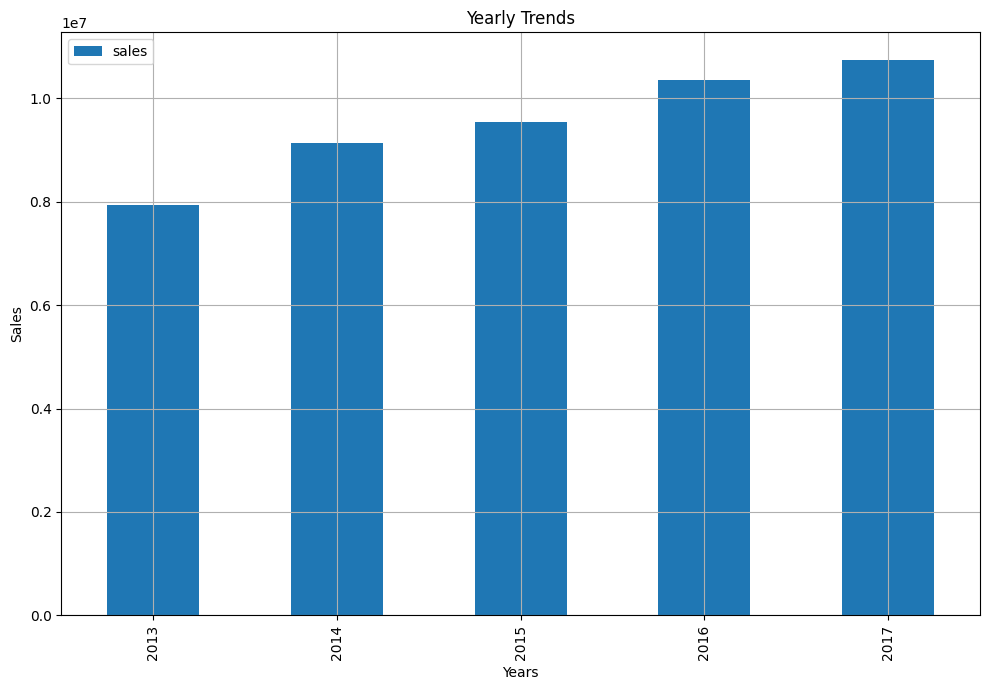

In [18]:
#yearly trends
yearly_trends=df.groupby('year')['sales'].sum()
yearly_trends.plot.bar(figsize=(10,7))
plt.title('Yearly Trends')
plt.xlabel('Years')
plt.ylabel('Sales')
plt.xticks(rotation=90)
plt.legend()
plt.tight_layout()
plt.grid()
plt.show()

In [19]:
df.set_index('date',inplace=True)

In [20]:
for lag in [1,7,14,30]:
    df[f'lag_{lag}']=df['sales'].shift(lag)

In [21]:
lags=df[['lag_1','lag_7','lag_14','lag_30']]

C:\Users\tg_mu\AppData\Local\Temp\ipykernel_24272\467285580.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


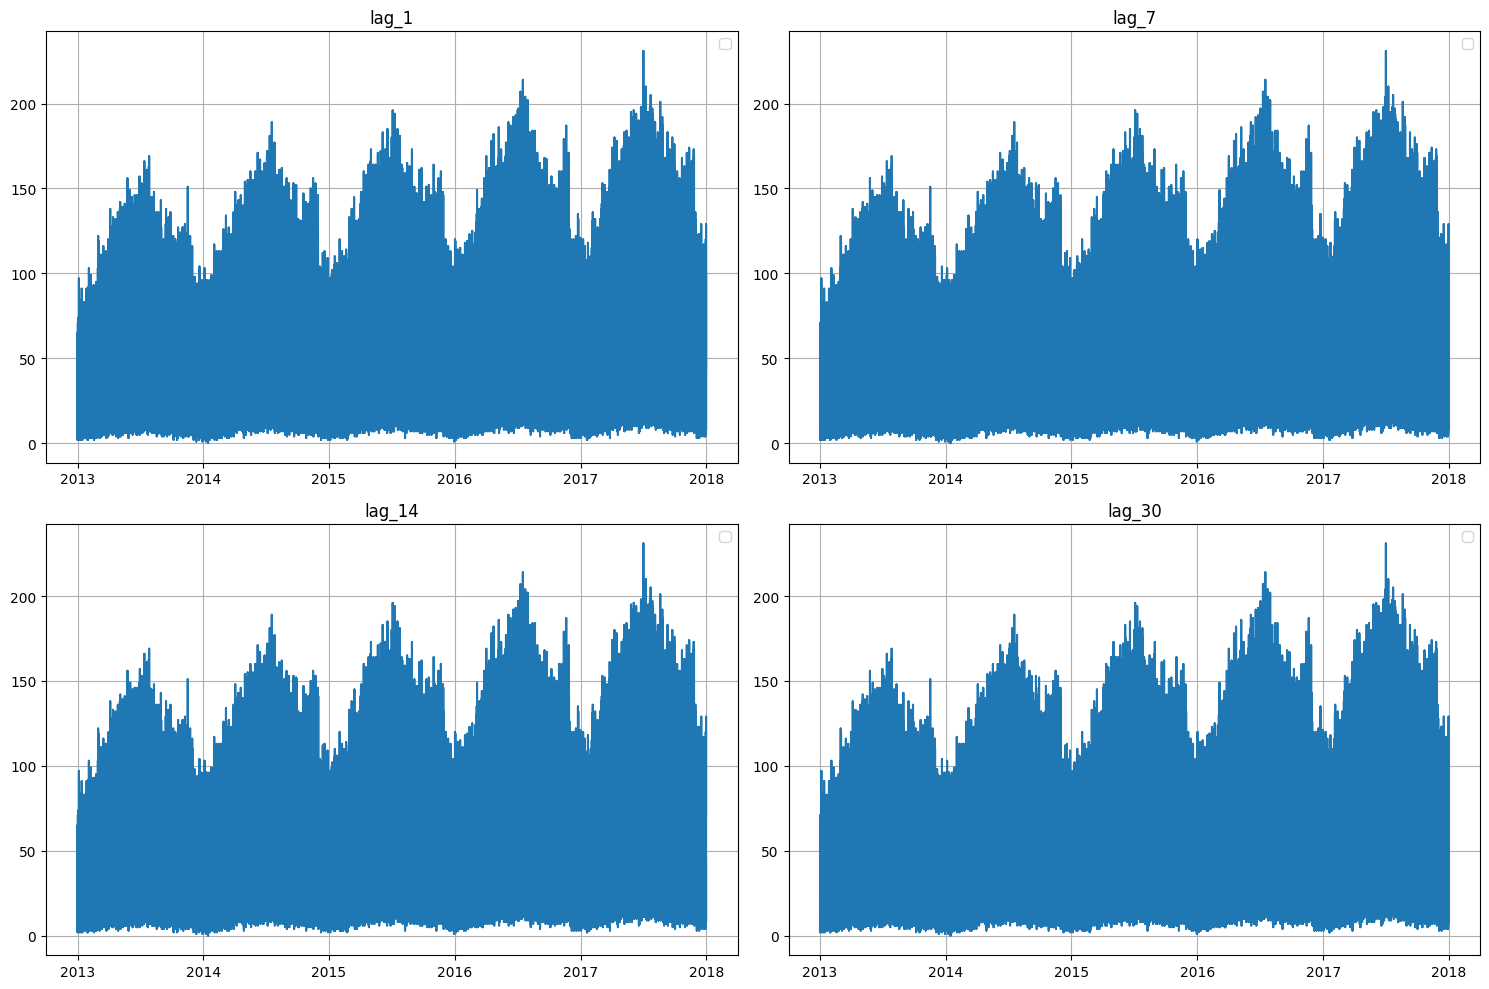

In [22]:
plt.figure(figsize=(15,10))
for index,col in enumerate(lags):
    plt.subplot(2,2,index+1)
    plt.plot(df[col])
    plt.title(col)
    plt.grid()
    plt.legend()
    plt.tight_layout()
plt.show()

In [23]:
df['rolling_mean_7']=df['sales'].shift(1).rolling(window=7).mean()
df['rolling_mean_30']=df['sales'].shift(1).rolling(window=30).mean()
df['rolling_std_7']=df['sales'].shift(1).rolling(window=7).std()

In [24]:
df['expanding_mean']=df['sales'].shift(1).expanding().mean()

In [25]:
rolling_mean=df[['rolling_mean_7','rolling_mean_30','rolling_std_7','expanding_mean']]

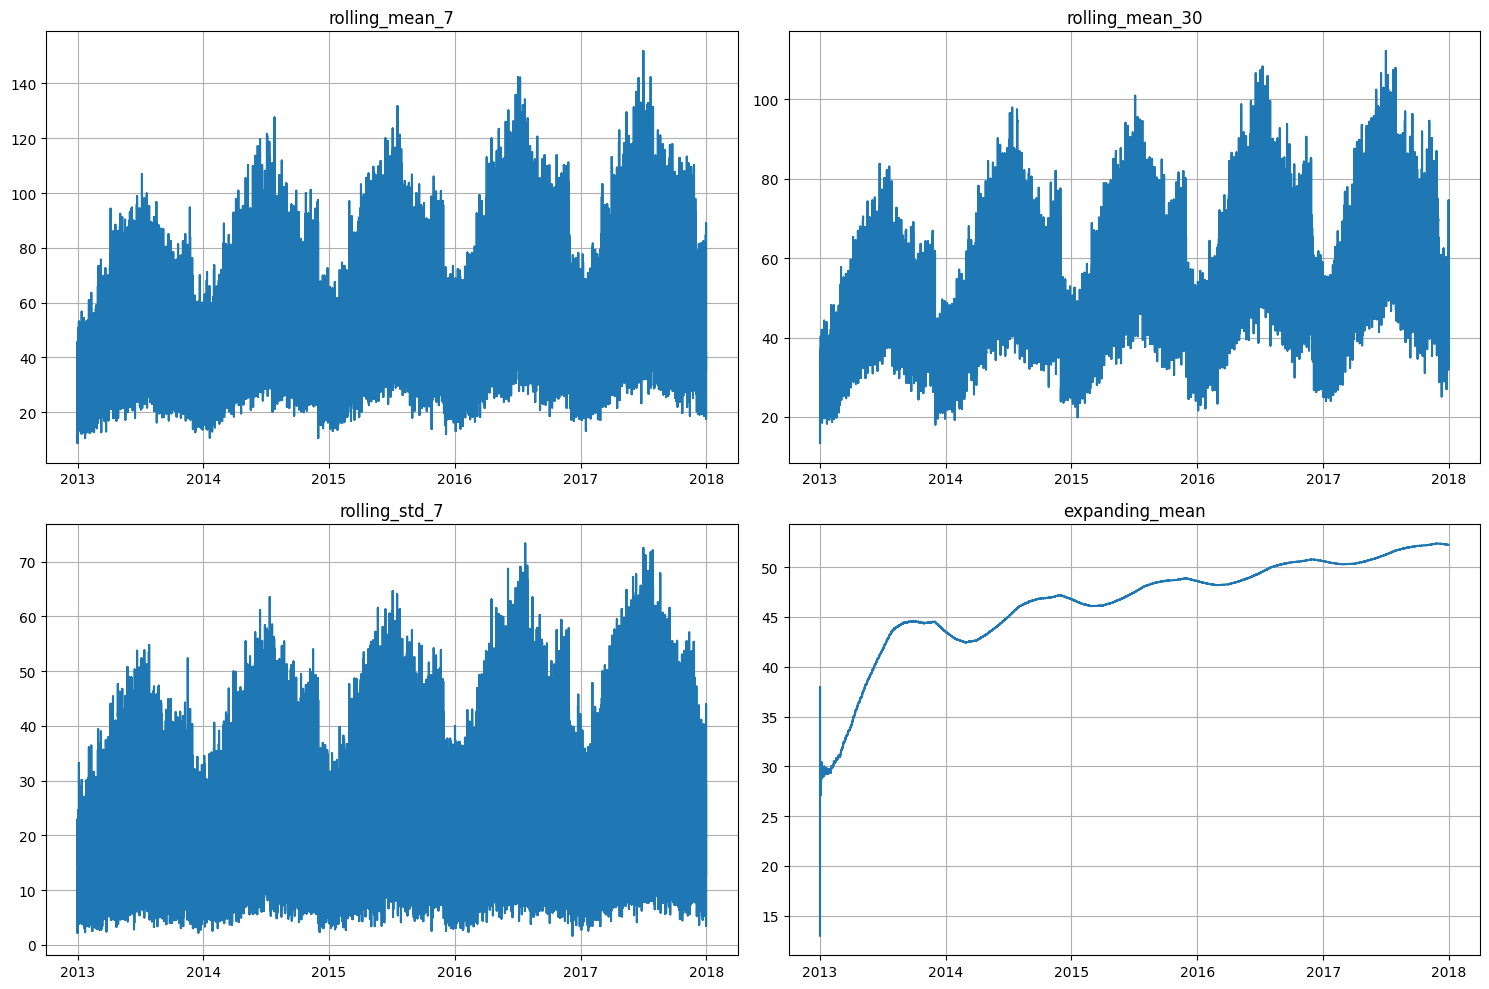

In [26]:
plt.figure(figsize=(15,10))
for index,col in enumerate(rolling_mean):
    plt.subplot(2,2,index+1)
    plt.plot(df[col])
    plt.title(col)
    plt.grid()
    plt.tight_layout()
plt.show()

In [27]:
df['month_sin']=np.sin(2*np.pi*df['month']/12)
df['month_cos']=np.cos(2*np.pi*df['month']/12)

In [28]:
df['dayofweek_sin']=np.sin(2*np.pi*df['dayofweek']/7)
df['dayofweek_cos']=np.cos(2*np.pi*df['dayofweek']/7)

In [29]:
df.dropna(inplace=True)

In [30]:
df_sample=df.iloc[:100000]
df_sample

,store,item,sales,day,week,month,quarter,year,dayofweek,is_weekend,...,lag_14,lag_30,rolling_mean_7,rolling_mean_30,rolling_std_7,expanding_mean,month_sin,month_cos,dayofweek_sin,dayofweek_cos
date,,,,,,,,,,,,,,,,,,,,,
2013-01-01,5,12,22,Tuesday,1,1,1,2013,1,False,...,56.0,13.0,33.428571,36.200000,8.462804,36.200000,0.5,0.866025,0.781831,0.623490
2013-01-01,4,12,36,Tuesday,1,1,1,2013,1,False,...,33.0,26.0,31.285714,36.500000,9.268482,35.741935,0.5,0.866025,0.781831,0.623490
2013-01-01,4,10,30,Tuesday,1,1,1,2013,1,False,...,47.0,27.0,32.142857,36.833333,9.406178,35.750000,0.5,0.866025,0.781831,0.623490
2013-01-01,5,10,31,Tuesday,1,1,1,2013,1,False,...,46.0,54.0,30.285714,36.933333,8.097619,35.575758,0.5,0.866025,0.781831,0.623490
2013-01-01,6,10,29,Tuesday,1,1,1,2013,1,False,...,43.0,35.0,31.571429,36.166667,7.230886,35.441176,0.5,0.866025,0.781831,0.623490
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2013-07-20,10,5,13,Saturday,29,7,3,2013,5,True,...,25.0,90.0,74.285714,63.966667,34.407917,42.953732,-0.5,-0.866025,-0.974928,-0.222521
2013-07-20,1,6,67,Saturday,29,7,3,2013,5,True,...,59.0,89.0,65.428571,61.400000,41.452210,42.953432,-0.5,-0.866025,-0.974928,-0.222521
2013-07-20,4,7,92,Saturday,29,7,3,2013,5,True,...,92.0,70.0,60.285714,60.666667,38.112615,42.953673,-0.5,-0.866025,-0.974928,-0.222521


In [31]:
df_sample.reset_index(inplace=True)

In [32]:
features = ['sales','dayofweek_sin','dayofweek_cos','month_sin','month_cos']

In [33]:
df_lstm=df_sample[features]

In [34]:
df_lstm

,sales,dayofweek_sin,dayofweek_cos,month_sin,month_cos
0,22,0.781831,0.623490,0.5,0.866025
1,36,0.781831,0.623490,0.5,0.866025
2,30,0.781831,0.623490,0.5,0.866025
3,31,0.781831,0.623490,0.5,0.866025
4,29,0.781831,0.623490,0.5,0.866025
...,...,...,...,...,...
99995,13,-0.974928,-0.222521,-0.5,-0.866025
99996,67,-0.974928,-0.222521,-0.5,-0.866025
99997,92,-0.974928,-0.222521,-0.5,-0.866025
99998,20,-0.974928,-0.222521,-0.5,-0.866025


In [35]:
split = int(len(df_lstm) * 0.8)
split

80000

In [36]:
train=df_lstm[:split]
test=df_lstm[split:]

In [37]:
print(train.shape)
print(test.shape)

(80000, 5)
(20000, 5)


In [38]:
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler()

In [39]:
train_scaled=scaler.fit_transform(train)
test_scaled=scaler.transform(test)

In [40]:
print(train_scaled.shape)
print(test_scaled.shape)

(80000, 5)
(20000, 5)


In [41]:
def create_sequences(data,look_back):

    X = []
    y = []

    for i in range(len(data) - look_back):
        X.append(data[i:i+look_back])
        y.append(data[i+look_back,0])

    return np.array(X), np.array(y)

In [42]:
look_back = 30

X_train, y_train = create_sequences(train_scaled,look_back)

X_test, y_test = create_sequences(test_scaled,look_back)

In [43]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(79970, 30, 5)
(19970, 30, 5)
(79970,)
(19970,)


In [44]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input,LSTM,Dense,Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [45]:
earlystopping=EarlyStopping(monitor='val_loss',
                            patience=10,
                            restore_best_weights=True)

In [46]:
model=Sequential()
model.add(Input(shape=(30,5)))
model.add(LSTM(64,return_sequences=False))
model.add(Dense(1))

In [47]:
model.compile(optimizer='adam',loss='mse',metrics=['mae'])

In [48]:
model.fit(X_train,y_train,epochs=10,validation_data=(X_test,y_test),batch_size=64,callbacks=[earlystopping])

Epoch 1/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 25s 19ms/step - loss: 0.0178 - mae: 0.1080 - val_loss: 0.0315 - val_mae: 0.1422
Epoch 2/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 21s 17ms/step - loss: 0.0174 - mae: 0.1070 - val_loss: 0.0291 - val_mae: 0.1403
Epoch 3/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 17s 14ms/step - loss: 0.0174 - mae: 0.1069 - val_loss: 0.0298 - val_mae: 0.1404
Epoch 4/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 22s 17ms/step - loss: 0.0173 - mae: 0.1066 - val_loss: 0.0289 - val_mae: 0.1401
Epoch 5/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 17s 13ms/step - loss: 0.0172 - mae: 0.1065 - val_loss: 0.0287 - val_mae: 0.1402
Epoch 6/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 25s 20ms/step - loss: 0.0172 - mae: 0.1064 - val_loss: 0.0297 - val_mae: 0.1403
Epoch 7/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 13s 10ms/step - loss: 0.0172 - mae: 0.1064 - val_loss: 0.0292 - val_mae: 0.1397
Epoch 8/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 15s 12ms/step - loss: 0.0172 - mae: 0.1063 - val_loss: 0.0291 - val_mae: 0.1397
Epoch 9/10
1250/1250 ━━━

In [49]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        17,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 53,957 (210.77 KB)

 Trainable params: 17,985 (70.25 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 35,972 (140.52 KB)

In [50]:
history=model.history.history

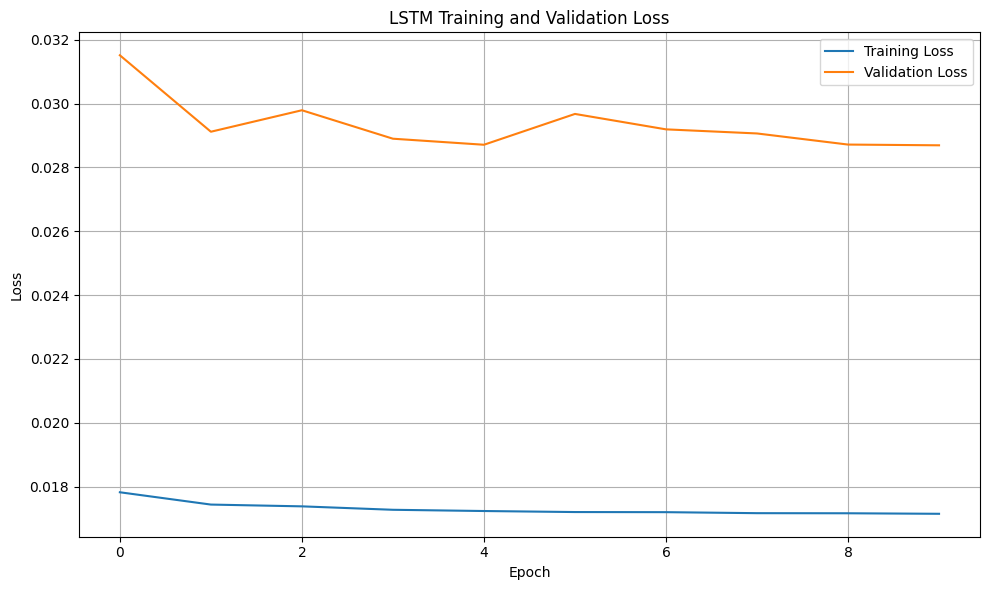

In [53]:
plt.figure(figsize=(10, 6))

plt.plot(history["loss"],
    label="Training Loss"
)

plt.plot(history["val_loss"],
    label="Validation Loss"
)

plt.title("LSTM Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()

plt.savefig(
    "visualizations/lstm_training_history_Loss.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

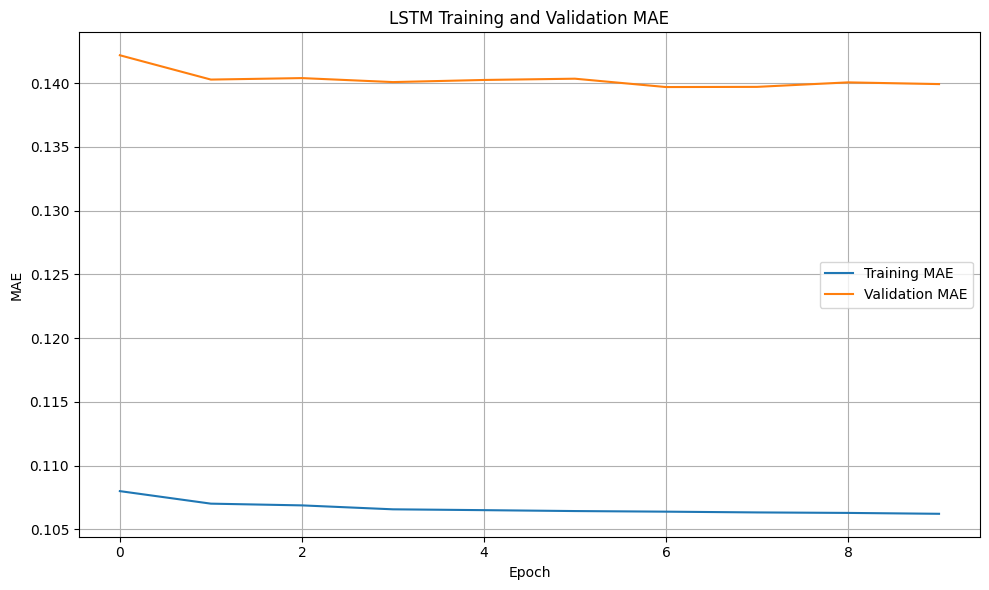

In [54]:
plt.figure(figsize=(10, 6))

plt.plot(history["mae"],
    label="Training MAE"
)

plt.plot(history["val_mae"],
    label="Validation MAE"
)

plt.title("LSTM Training and Validation MAE")
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.legend()
plt.grid(True)

plt.tight_layout()

plt.savefig(
    "visualizations/lstm_training_history_MAE.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [55]:
y_pred_scaled=model.predict(X_test)

625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


In [56]:

dummy = np.zeros((len(y_test), train_scaled.shape[1]))

dummy[:, 0] = y_test.ravel()      # sales is the first column

y_test_actual = scaler.inverse_transform(dummy)[:, 0]

In [57]:
dummy = np.zeros((len(y_pred_scaled), train_scaled.shape[1]))

dummy[:, 0] = y_pred_scaled.ravel()

y_pred_actual = scaler.inverse_transform(dummy)[:, 0]

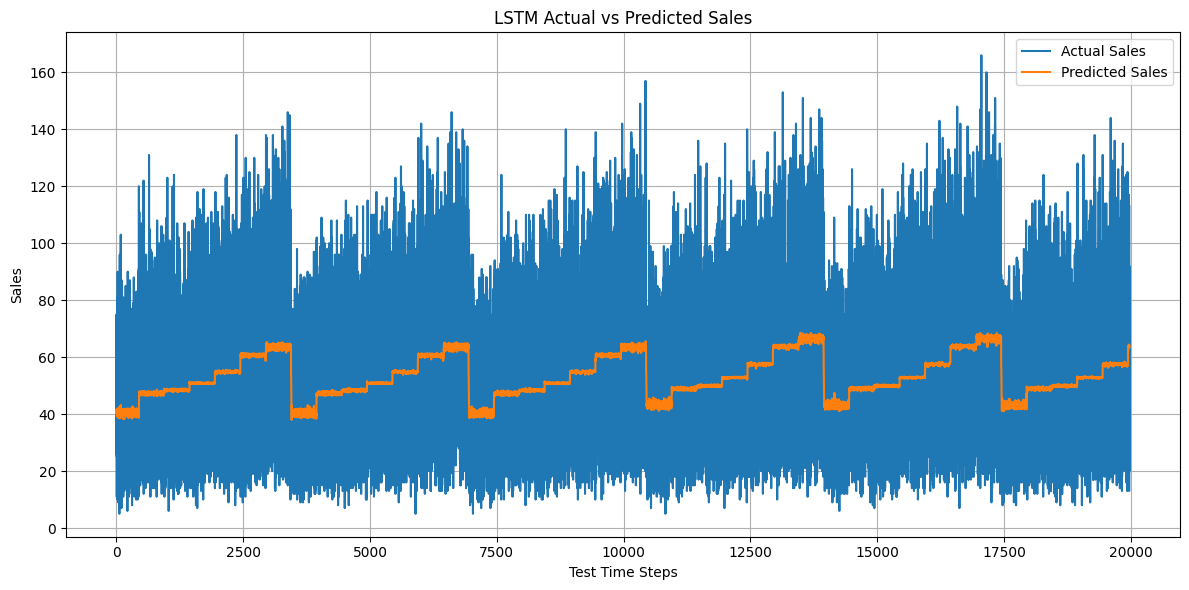

In [59]:
plt.figure(figsize=(12, 6))

plt.plot(
    y_test_actual,
    label="Actual Sales"
)

plt.plot(
    y_pred_actual,
    label="Predicted Sales"
)

plt.title("LSTM Actual vs Predicted Sales")
plt.xlabel("Test Time Steps")
plt.ylabel("Sales")

plt.legend()
plt.grid(True)

plt.tight_layout()

plt.savefig(
    "visualizations/lstm_actual_vs_predicted.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [58]:
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

print("MAE :", mean_absolute_error(y_test_actual, y_pred_actual))
print("RMSE:", root_mean_squared_error(y_test_actual, y_pred_actual))
print("R²  :", r2_score(y_test_actual, y_pred_actual))

MAE : 21.548021049393853
RMSE: 26.08654437323383
R²  : 0.0568338701663198


## LSTM Model Performance

The LSTM model was evaluated on the test dataset using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R² Score.

| Metric | Result |
|---|---:|
| **MAE** | **21.5480** |
| **RMSE** | **26.0865** |
| **R² Score** | **0.0568** |

### Interpretation

The LSTM model achieved an MAE of **21.5480** and an RMSE of **26.0865**.

The R² score of **0.0568** indicates that the current LSTM configuration explains only a relatively small proportion of the variation in the test data.

Therefore, the LSTM model provides a useful deep-learning benchmark, but its current configuration may require further optimization to achieve stronger forecasting performance.

Potential improvements include:

- Hyperparameter tuning
- Different look-back windows
- Additional relevant features
- Different LSTM architectures
- Dropout regularization
- More training epochs with appropriate early stopping
- Alternative scaling strategies